# 📈 Análisis Cuantitativo de Portafolio de Inversiones
**Descripción:** Este notebook contiene un motor de análisis cuantitativo desarrollado en Python. Audita el rendimiento histórico, calcula métricas de riesgo institucional (VaR, Sharpe, Max Drawdown), evalúa correlaciones y ejecuta simulaciones de Monte Carlo y pruebas de estrés sobre una cartera multiactivo.

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style="whitegrid")


## 1. Definición de la Cartera y Parámetros
Configuración de los pesos objetivo de los activos (Growth / Tech / Cripto) y los índices de referencia.

In [17]:
portfolio_weights = {
    'BTC-USD': 0.218, 'MSFT': 0.142, 'NVDA': 0.120, 'PAGS': 0.094,
    'META': 0.081, 'MELI': 0.074, 'ASML': 0.064, 'GOOGL': 0.051,
    'V': 0.047, 'AMZN': 0.043, 'LLY': 0.033, 'TSLA': 0.032
}

tickers = list(portfolio_weights.keys())
benchmarks = {'^GSPC': 'S&P 500', '^IXIC': 'NASDAQ'}
RISK_FREE = 0.045

# Fechas de análisis (2 años históricos)
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=2*365)

## 2. Extracción y Preprocesamiento de Datos
Descarga de series temporales mediante la API de Yahoo Finance y cálculo de retornos logarítmicos/diarios.

In [18]:
all_tickers = tickers + list(benchmarks.keys())
data = yf.download(all_tickers, start="2019-01-01", end=end_date, progress=False)['Close']

# Retornos diarios
returns = data.pct_change().dropna(how='all')

# Aislar retornos de la cartera específica
weights_series = pd.Series(portfolio_weights)
portfolio_returns = (returns[tickers].fillna(0) * weights_series).sum(axis=1)

print("Datos descargados y preprocesados correctamente.")

Datos descargados y preprocesados correctamente.


C:\Users\el_ca\AppData\Local\Temp\ipykernel_22576\2069474164.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna(how='all')


## 3. Métricas de Rendimiento Institucional (KPIs)
Cálculo de la Tasa de Crecimiento Anual Compuesto (CAGR), Volatilidad Anualizada, Sharpe Ratio y Maximum Drawdown.

In [19]:
def calculate_metrics(ret_series, rf=RISK_FREE):
    ret_series = ret_series.dropna()
    cum_returns = (1 + ret_series).cumprod()
    cagr = cum_returns.iloc[-1] ** (252 / len(ret_series)) - 1
    vol = ret_series.std() * np.sqrt(252)
    sharpe = (cagr - rf) / vol
    max_dd = (cum_returns / cum_returns.cummax() - 1).min()
    
    return pd.Series({
        'CAGR': f"{cagr*100:.2f}%",
        'Volatilidad Anual': f"{vol*100:.2f}%",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown': f"{max_dd*100:.2f}%"
    })

metrics_df = pd.DataFrame({
    'Mi Cartera': calculate_metrics(portfolio_returns.loc[start_date:end_date]),
    'S&P 500': calculate_metrics(returns.loc[start_date:end_date, '^GSPC']),
    'NASDAQ': calculate_metrics(returns.loc[start_date:end_date, '^IXIC'])
})
display(metrics_df)

,Mi Cartera,S&P 500,NASDAQ
CAGR,18.32%,12.84%,17.18%
Volatilidad Anual,19.88%,13.34%,17.92%
Sharpe Ratio,0.70,0.62,0.71
Max Drawdown,-20.96%,-18.90%,-24.32%


## 4. Matriz de Correlación de Activos
Análisis de diversificación mediante el coeficiente de correlación de Pearson, aplicando una máscara para limpieza visual.

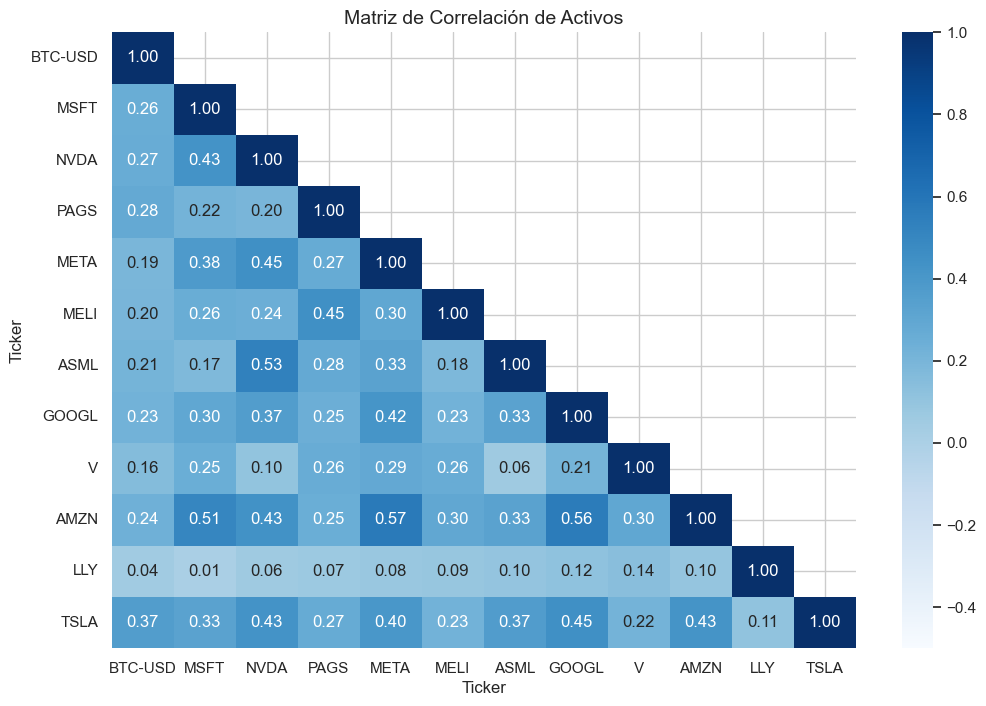

In [20]:
plt.figure(figsize=(12, 8))
corr_matrix = returns.loc[start_date:end_date, tickers].corr()

# Máscara para la diagonal superior (manteniendo la diagonal principal)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='Blues', vmin=-0.5, vmax=1)
plt.title('Matriz de Correlación de Activos', fontsize=14)
plt.show()

## 4.5. Composición de la Cartera y Tenencias Actuales
Desglose del peso individual de los activos (Top Posiciones) y la distribución agregada por sectores económicos, replicando formatos de reporte institucional.

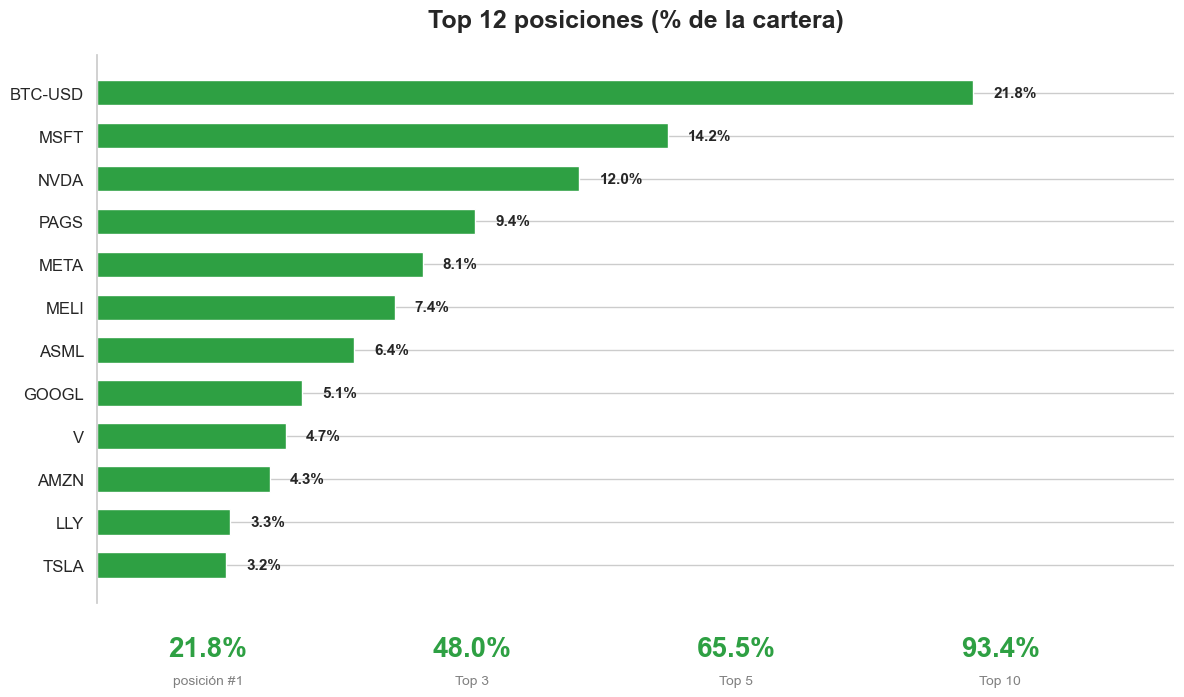

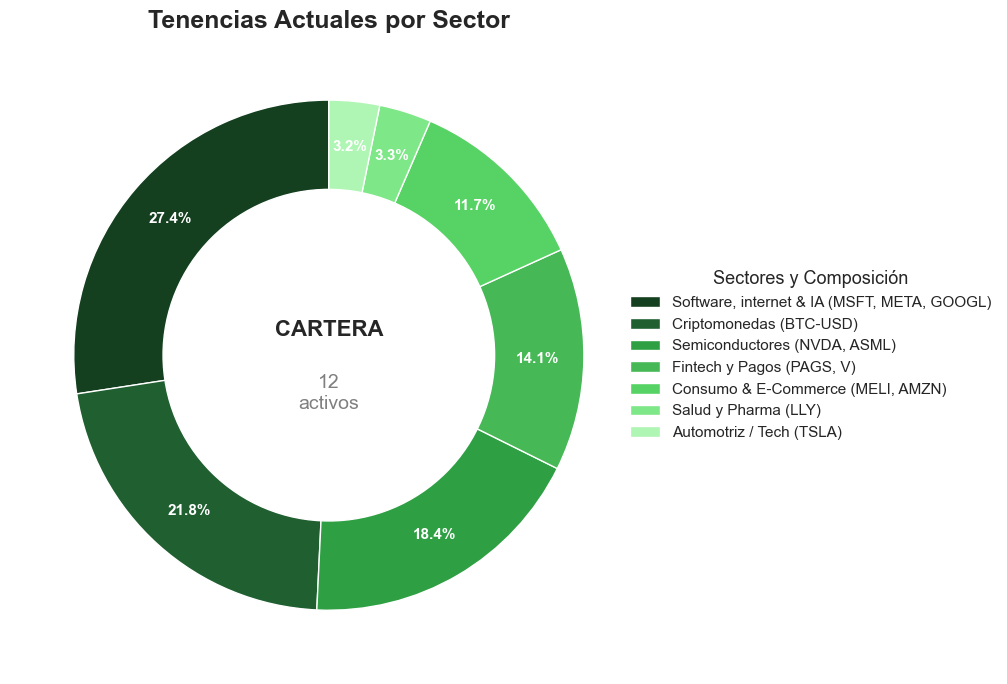

In [21]:
# ---------------------------------------------------------
# 1. PREPARACIÓN DE DATOS Y MAPEO DE SECTORES
# ---------------------------------------------------------
sector_map = {
    'BTC-USD': 'Criptomonedas', 
    'MSFT': 'Software, internet & IA',
    'NVDA': 'Semiconductores', 
    'ASML': 'Semiconductores',
    'GOOGL': 'Software, internet & IA',
    'META': 'Software, internet & IA', 
    'MELI': 'Consumo & E-Commerce',
    'PAGS': 'Fintech y Pagos', 
    'V': 'Fintech y Pagos', 
    'AMZN': 'Consumo & E-Commerce',
    'LLY': 'Salud y Pharma', 
    'TSLA': 'Automotriz / Tech'
}

df_pesos = pd.DataFrame(list(portfolio_weights.items()), columns=['Ticker', 'Peso'])
df_pesos = df_pesos.sort_values(by='Peso', ascending=True) # Orden ascendente para el gráfico de barras

sector_data = [{'Ticker': k, 'Sector': sector_map[k], 'Peso': v} for k, v in portfolio_weights.items()]
df_sec = pd.DataFrame(sector_data)
sector_agg = df_sec.groupby('Sector')['Peso'].sum().sort_values(ascending=False)
tickers_por_sector = df_sec.groupby('Sector')['Ticker'].apply(lambda x: ', '.join(x)).to_dict()

# ---------------------------------------------------------
# 2. GRÁFICO 1: TOP POSICIONES Y ACUMULADOS (BARRAS)
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12, 7))

bars = ax1.barh(df_pesos['Ticker'], df_pesos['Peso'], color='#2ea043', height=0.6)

for bar in bars:
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width()*100:.1f}%', va='center', ha='left', fontsize=11, fontweight='bold')

ax1.set_title('Top 12 posiciones (% de la cartera)', fontsize=18, fontweight='bold', pad=20)
ax1.set_xlim(0, df_pesos['Peso'].max() + 0.05)

for spine in ['top', 'right', 'bottom']:
    ax1.spines[spine].set_visible(False)
ax1.xaxis.set_visible(False)
ax1.tick_params(axis='y', left=False, labelsize=12)

# Métricas acumuladas en la base
w_desc = df_pesos.sort_values(by='Peso', ascending=False)['Peso'].values
top1, top3, top5, top10 = w_desc[0], w_desc[:3].sum(), w_desc[:5].sum(), w_desc[:10].sum()

plt.figtext(0.18, 0.05, f'{top1*100:.1f}%', ha='center', fontsize=20, fontweight='bold', color='#2ea043')
plt.figtext(0.18, 0.01, 'posición #1', ha='center', fontsize=10, color='gray')

plt.figtext(0.40, 0.05, f'{top3*100:.1f}%', ha='center', fontsize=20, fontweight='bold', color='#2ea043')
plt.figtext(0.40, 0.01, 'Top 3', ha='center', fontsize=10, color='gray')

plt.figtext(0.62, 0.05, f'{top5*100:.1f}%', ha='center', fontsize=20, fontweight='bold', color='#2ea043')
plt.figtext(0.62, 0.01, 'Top 5', ha='center', fontsize=10, color='gray')

plt.figtext(0.84, 0.05, f'{top10*100:.1f}%', ha='center', fontsize=20, fontweight='bold', color='#2ea043')
plt.figtext(0.84, 0.01, 'Top 10', ha='center', fontsize=10, color='gray')

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

# ---------------------------------------------------------
# 3. GRÁFICO 2: TENENCIAS POR SECTOR (DONUT CON LEYENDA)
# ---------------------------------------------------------
fig, ax2 = plt.subplots(figsize=(14, 7))

colores_anillo = ['#144020', '#1f5f30', '#2ea043', '#46b856', '#56d364', '#7ee787', '#aff5b4', '#d7ffdb']

wedges, texts, autotexts = ax2.pie(
    sector_agg, 
    labels=None, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colores_anillo[:len(sector_agg)], 
    pctdistance=0.82,
    textprops=dict(color="white", fontsize=11, fontweight='bold')
)

centro_blanco = plt.Circle((0,0), 0.65, fc='white')
fig.gca().add_artist(centro_blanco)

plt.text(0, 0.1, 'CARTERA', ha='center', va='center', fontsize=16, fontweight='bold')
plt.text(0, -0.15, f'{len(portfolio_weights)}\nactivos', ha='center', va='center', fontsize=14, color='gray')

ax2.set_title('Tenencias Actuales por Sector', fontsize=18, fontweight='bold')

legend_labels = [f"{sector} ({tickers_por_sector[sector]})" for sector in sector_agg.index]

ax2.legend(
    wedges, 
    legend_labels,
    title="Sectores y Composición",
    loc="center left",
    bbox_to_anchor=(0.95, 0.5),
    fontsize=11,
    title_fontsize=13,
    frameon=False
)

plt.tight_layout()
plt.show()

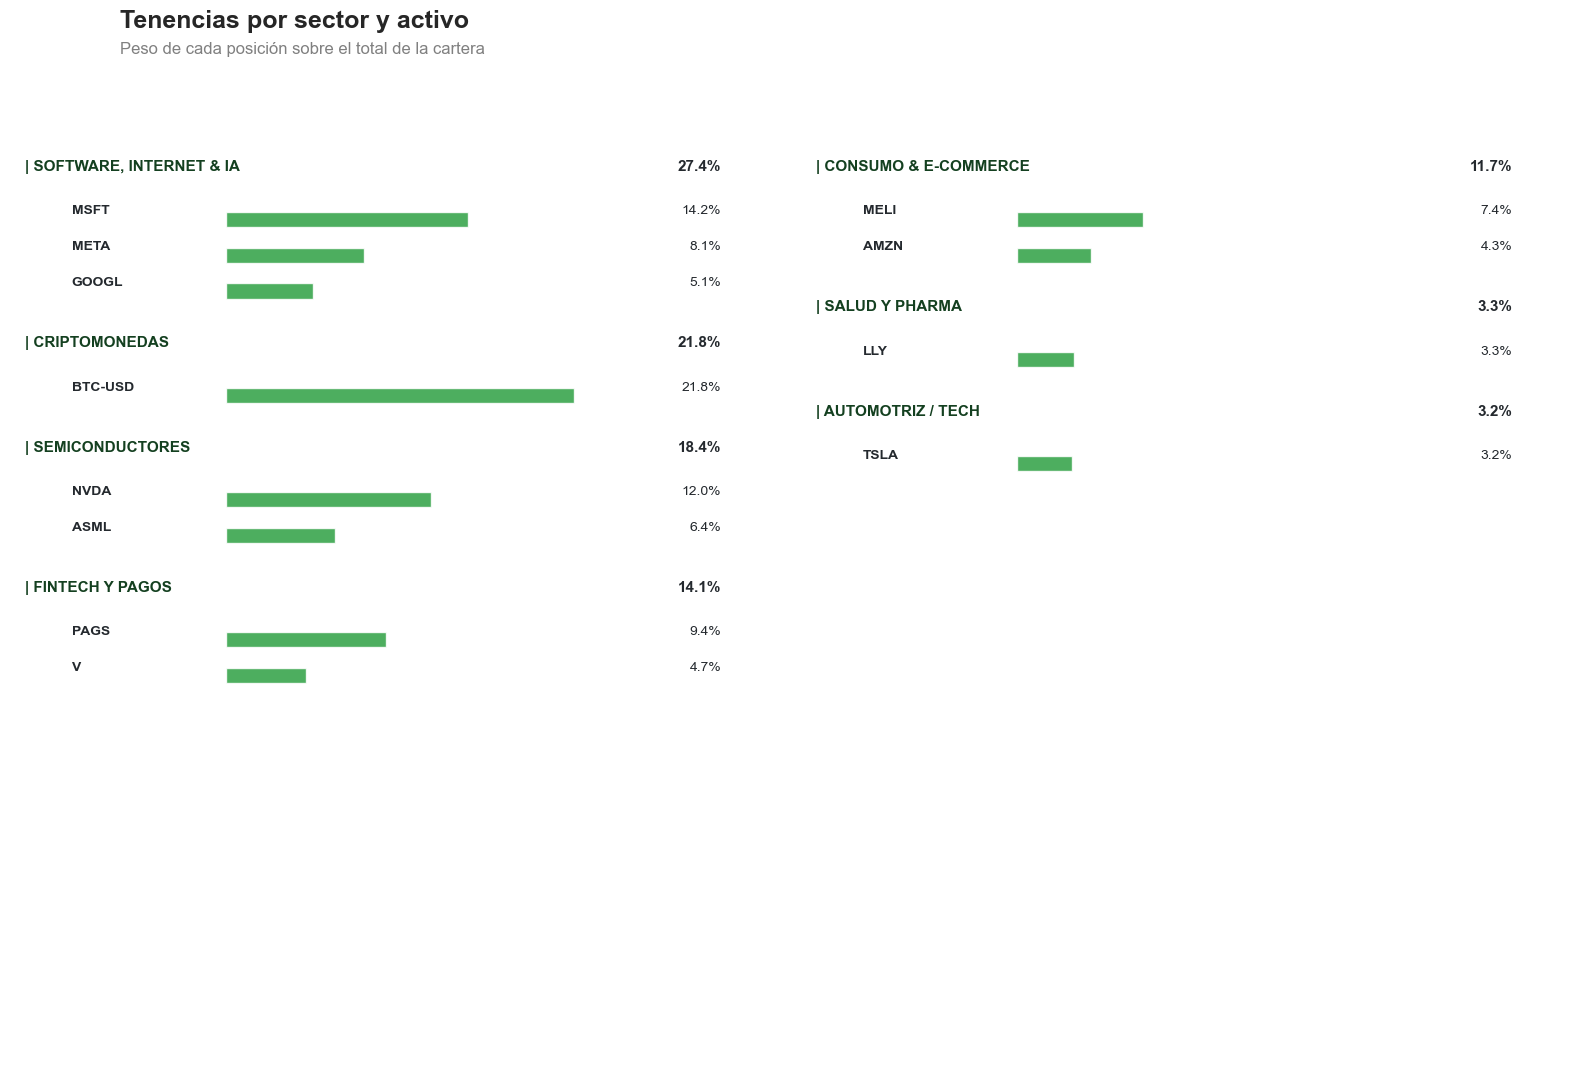

In [27]:
# ---------------------------------------------------------
# 4.6. GRÁFICO: TENENCIAS POR SECTOR Y ACTIVO (ESTILO REPORTE)
# ---------------------------------------------------------

# 1. Agrupar activos por sector y calcular totales
sector_dict = {}
for ticker, weight in portfolio_weights.items():
    sec = sector_map.get(ticker, 'Otros')
    if sec not in sector_dict:
        sector_dict[sec] = []
    sector_dict[sec].append((ticker, weight))

# Ordenar sectores por peso total descendente
sector_totals = {sec: sum(w for _, w in assets) for sec, assets in sector_dict.items()}
sorted_sectors = sorted(sector_totals.keys(), key=lambda x: sector_totals[x], reverse=True)

# 2. Configurar la figura en 2 columnas
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 11))
ax_left.axis('off')
ax_right.axis('off')

# Dividir los sectores equitativamente entre columna izquierda y derecha
mid_point = len(sorted_sectors) // 2 + len(sorted_sectors) % 2
left_sectors = sorted_sectors[:mid_point]
right_sectors = sorted_sectors[mid_point:]

def draw_sector_column(ax, sectors_list, start_y=0.95):
    y = start_y
    line_height = 0.038
    for sec in sectors_list:
        assets = sorted(sector_dict[sec], key=lambda x: x[1], reverse=True)
        sec_total = sector_totals[sec]
        
        # Cabecera del Sector
        ax.text(0.02, y, f"| {sec.upper()}", fontsize=11, fontweight='bold', color='#144020', transform=ax.transAxes)
        ax.text(0.92, y, f"{sec_total*100:.1f}%", fontsize=11, fontweight='bold', color='#24292e', ha='right', transform=ax.transAxes)
        y -= line_height * 1.2
        
        # Filas de los activos pertenecientes al sector
        for ticker, weight in assets:
            ax.text(0.08, y, ticker, fontsize=10, fontweight='bold', color='#24292e', transform=ax.transAxes)
            
            # Mini barra horizontal de proporción
            bar_x = 0.28
            bar_width = min(weight * 2.2, 0.45) # Escala visual ajustada
            ax.barh(y - 0.005, bar_width, height=0.016, color='#2ea043', alpha=0.85, left=bar_x, transform=ax.transAxes, align='center')
            
            ax.text(0.92, y, f"{weight*100:.1f}%", fontsize=10, color='#24292e', ha='right', transform=ax.transAxes)
            y -= line_height
            
        y -= line_height * 0.7 # Espacio separador entre bloques de sectores

# Dibujar ambas columnas
draw_sector_column(ax_left, left_sectors)
draw_sector_column(ax_right, right_sectors)

# Títulos superiores generales
plt.suptitle("Tenencias por sector y activo", fontsize=18, fontweight='bold', x=0.08, y=0.98, ha='left')
plt.figtext(0.08, 0.94, "Peso de cada posición sobre el total de la cartera", fontsize=12, color='gray', ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 5. GRÁFICO: RIESGO VS. RETORNO POR ACTIVO (CON BENCHMARKS)

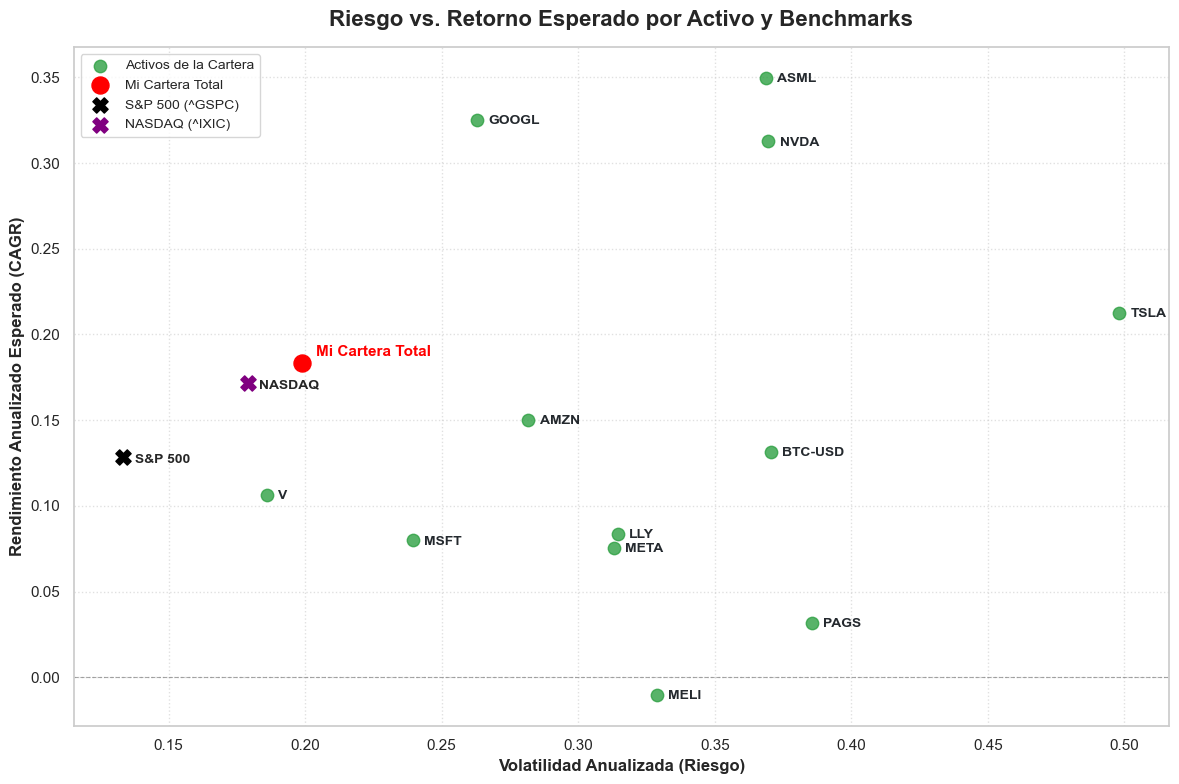

In [23]:
# 1. Filtrar solo los tickers de la cartera que existan en el DataFrame de retornos
valid_tickers = [t for t in portfolio_weights.keys() if t in returns.columns]
weights_series_clean = pd.Series({t: portfolio_weights[t] for t in valid_tickers})
weights_series_clean = weights_series_clean / weights_series_clean.sum()

# 2. Calcular retornos diarios de la cartera para el periodo seleccionado
port_rets_period = (returns[valid_tickers].loc[start_date:end_date].fillna(0) * weights_series_clean).sum(axis=1)
cum_port_period = (1 + port_rets_period).cumprod()

# 3. Calcular métricas individuales para cada activo
asset_metrics = pd.DataFrame(index=valid_tickers)
asset_metrics['Volatilidad'] = returns[valid_tickers].loc[start_date:end_date].std() * np.sqrt(252)
cum_assets = (1 + returns[valid_tickers].loc[start_date:end_date]).cumprod()
asset_metrics['CAGR'] = cum_assets.iloc[-1] ** (252 / len(cum_assets)) - 1

# 4. Métricas de la Cartera Total
vol_port = port_rets_period.std() * np.sqrt(252)
cagr_port = cum_port_period.iloc[-1] ** (252 / len(cum_port_period)) - 1

# 5. Métricas para los benchmarks (S&P 500 y NASDAQ)
vol_sp = returns.loc[start_date:end_date, '^GSPC'].std() * np.sqrt(252)
cum_sp = (1 + returns.loc[start_date:end_date, '^GSPC']).cumprod()
cagr_sp = cum_sp.iloc[-1] ** (252 / len(cum_sp)) - 1

vol_nas = returns.loc[start_date:end_date, '^IXIC'].std() * np.sqrt(252)
cum_nas = (1 + returns.loc[start_date:end_date, '^IXIC']).cumprod()
cagr_nas = cum_nas.iloc[-1] ** (252 / len(cum_nas)) - 1

# --- Generación del Gráfico ---
plt.figure(figsize=(12, 8))

# Activos individuales
plt.scatter(asset_metrics['Volatilidad'], asset_metrics['CAGR'], color='#2ea043', s=80, alpha=0.8, label='Activos de la Cartera')

for ticker, row in asset_metrics.iterrows():
    plt.annotate(ticker, (row['Volatilidad'], row['CAGR']), 
                 textcoords="offset points", xytext=(8,-3), ha='left', fontsize=10, fontweight='bold', color='#24292e')

# Cartera Total (Rojo destacado)
plt.scatter(vol_port, cagr_port, color='red', s=150, zorder=5, label='Mi Cartera Total')
plt.annotate('Mi Cartera Total', (vol_port, cagr_port), 
             textcoords="offset points", xytext=(10,5), ha='left', fontsize=11, fontweight='bold', color='red')

# Benchmarks (S&P 500 y NASDAQ con cruces 'X')
plt.scatter(vol_sp, cagr_sp, color='black', marker='X', s=120, zorder=5, label='S&P 500 (^GSPC)')
plt.annotate('S&P 500', (vol_sp, cagr_sp), textcoords="offset points", xytext=(8,-4), fontsize=10, fontweight='bold')

plt.scatter(vol_nas, cagr_nas, color='purple', marker='X', s=120, zorder=5, label='NASDAQ (^IXIC)')
plt.annotate('NASDAQ', (vol_nas, cagr_nas), textcoords="offset points", xytext=(8,-4), fontsize=10, fontweight='bold')

# Estética general
plt.title('Riesgo vs. Retorno Esperado por Activo y Benchmarks', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Volatilidad Anualizada (Riesgo)', fontsize=12, fontweight='bold')
plt.ylabel('Rendimiento Anualizado Esperado (CAGR)', fontsize=12, fontweight='bold')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

## 6. GRÁFICO: CURVA SUBMARINA (DRAWDOWN HISTÓRICO)




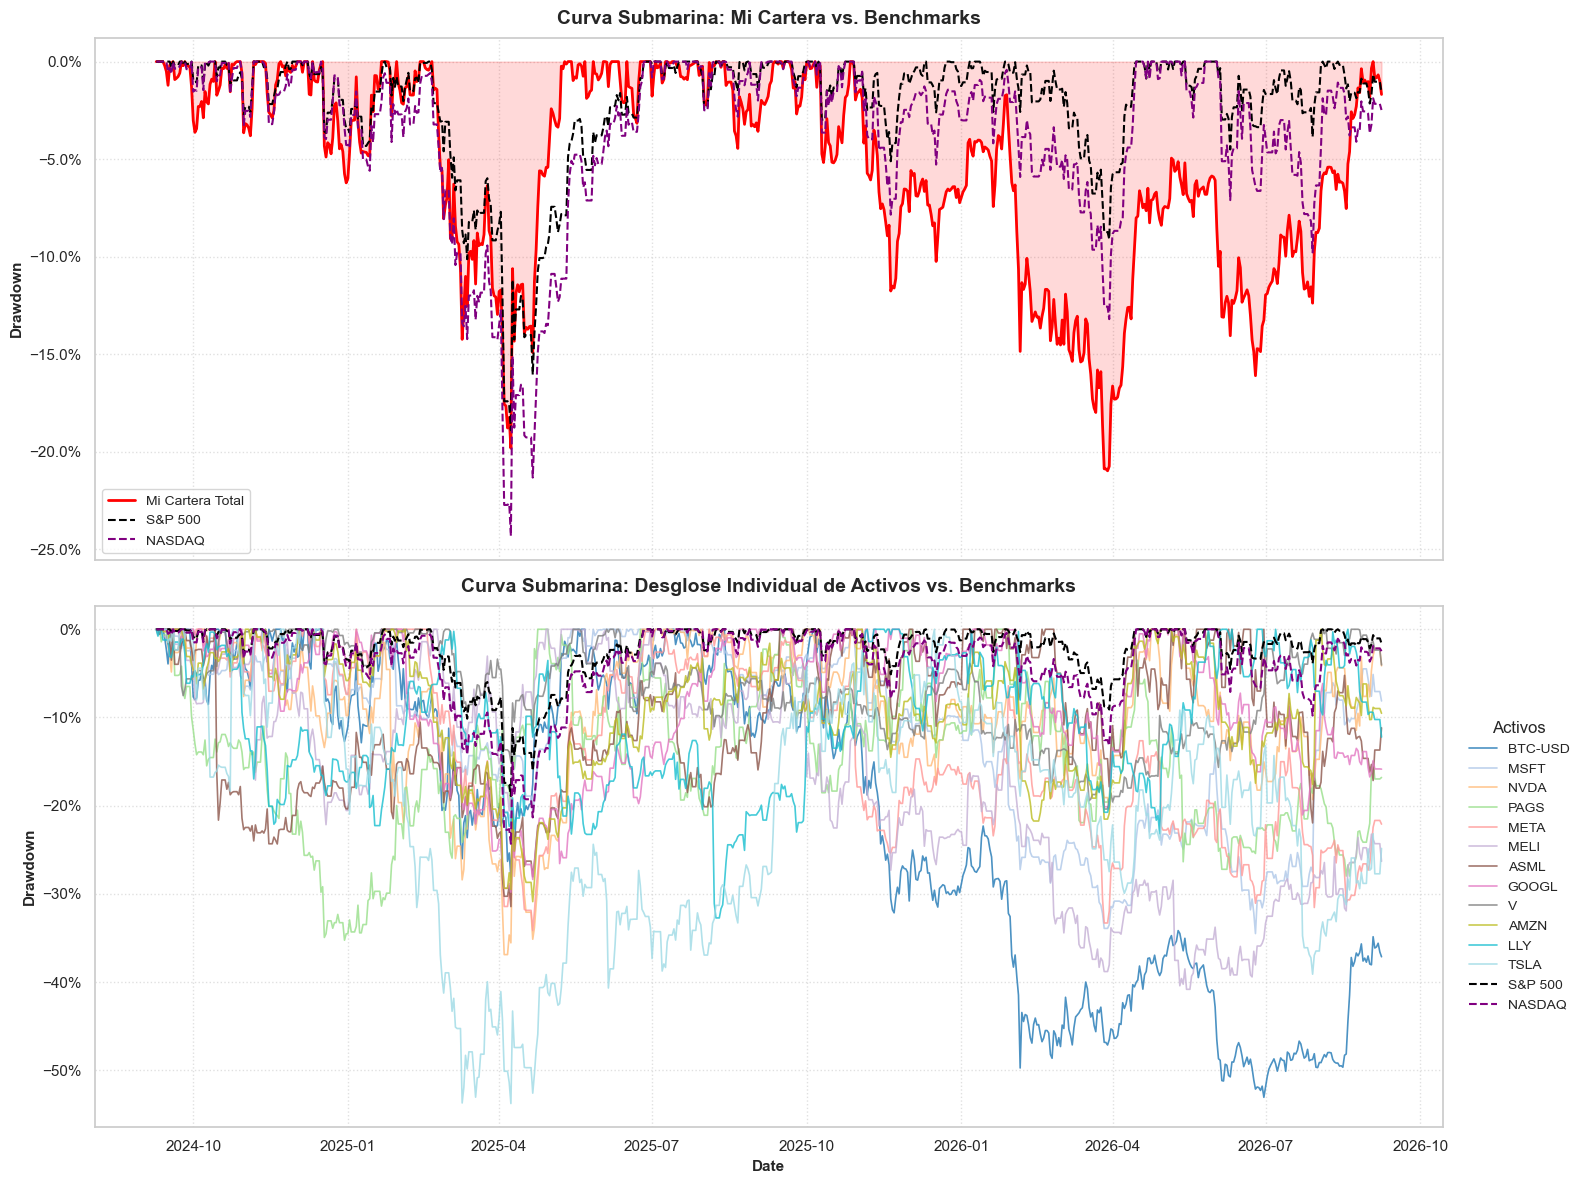

In [26]:
# 1. Cálculo de series y drawdowns
wealth_assets = (1 + returns[valid_tickers].loc[start_date:end_date]).cumprod()
wealth_port = (1 + port_rets_period).cumprod()
wealth_sp = (1 + returns.loc[start_date:end_date, '^GSPC'].dropna()).cumprod()
wealth_nas = (1 + returns.loc[start_date:end_date, '^IXIC'].dropna()).cumprod()

dd_assets = (wealth_assets / wealth_assets.cummax()) - 1
dd_port = (wealth_port / wealth_port.cummax()) - 1
dd_sp = (wealth_sp / wealth_sp.cummax()) - 1
dd_nas = (wealth_nas / wealth_nas.cummax()) - 1

# 2. Configuración de la figura con 2 subplots apilados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# --- SUBPLOT 1: Mi Cartera vs Benchmarks ---
ax1.fill_between(dd_port.index, dd_port, 0, color='red', alpha=0.15)
ax1.plot(dd_port.index, dd_port, color='red', linewidth=2, label='Mi Cartera Total')
ax1.plot(dd_sp.index, dd_sp, color='black', linestyle='--', linewidth=1.5, label='S&P 500')
ax1.plot(dd_nas.index, dd_nas, color='purple', linestyle='--', linewidth=1.5, label='NASDAQ')

ax1.set_title('Curva Submarina: Mi Cartera vs. Benchmarks', fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel('Drawdown', fontsize=11, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', frameon=True, fontsize=10)

# --- SUBPLOT 2: Acciones Desglosadas con Leyenda Interactiva ---
# Usamos una paleta de colores para diferenciar cada activo
import matplotlib.cm as cm
colors = cm.tab20(np.linspace(0, 1, len(valid_tickers)))

for i, ticker in enumerate(valid_tickers):
    ax2.plot(dd_assets.index, dd_assets[ticker], linewidth=1.2, alpha=0.8, color=colors[i], label=ticker)

# Agregar también los benchmarks en el panel inferior como referencia
ax2.plot(dd_sp.index, dd_sp, color='black', linestyle='--', linewidth=1.5, label='S&P 500')
ax2.plot(dd_nas.index, dd_nas, color='purple', linestyle='--', linewidth=1.5, label='NASDAQ')

ax2.set_title('Curva Submarina: Desglose Individual de Activos vs. Benchmarks', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('Drawdown', fontsize=11, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# Leyenda lateral desplazada para no superponerse con las líneas
ax2.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=10, title="Activos")

# Formatear ambos ejes Y como porcentaje
import matplotlib.ticker as mtick
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## 7. Simulación de Monte Carlo
Proyección estocástica de 1,000 trayectorias posibles para los próximos 252 días de trading, calculando los escenarios mediano y pesimista (VaR al 5%).

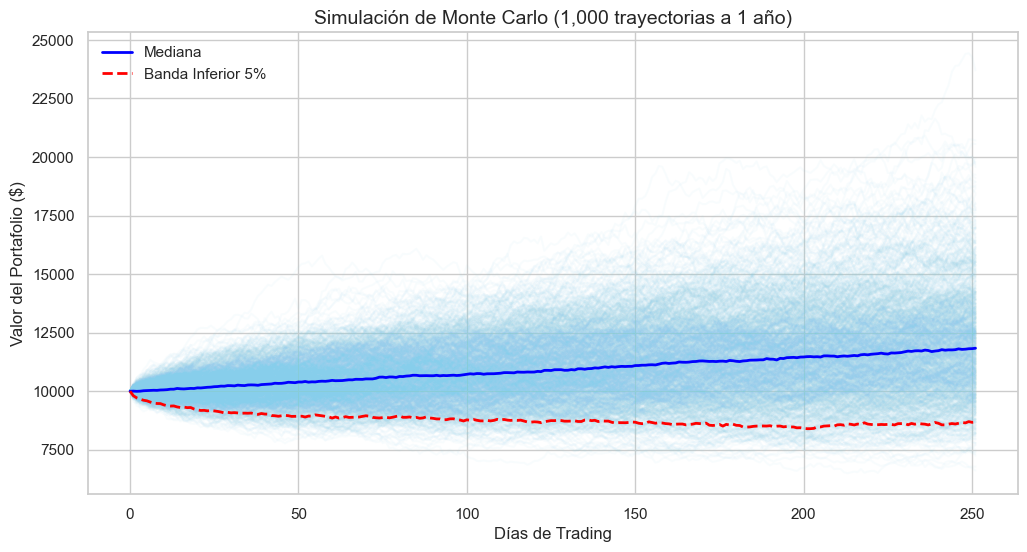

In [28]:
sim_days = 252
simulations = 1000
mu = portfolio_returns.loc[start_date:end_date].mean()
sigma = portfolio_returns.loc[start_date:end_date].std()

sim_results = np.zeros((sim_days, simulations))
sim_results[0] = 10000  # Capital base ficticio

for i in range(1, sim_days):
    shocks = np.random.normal(mu, sigma, simulations)
    sim_results[i] = sim_results[i-1] * (1 + shocks)

plt.figure(figsize=(12, 6))
plt.plot(sim_results, color='skyblue', alpha=0.05)
plt.plot(np.percentile(sim_results, 50, axis=1), color='blue', linewidth=2, label='Mediana')
plt.plot(np.percentile(sim_results, 5, axis=1), color='red', linewidth=2, linestyle='--', label='Banda Inferior 5%')
plt.title('Simulación de Monte Carlo (1,000 trayectorias a 1 año)', fontsize=14)
plt.xlabel('Días de Trading')
plt.ylabel('Valor del Portafolio ($)')
plt.legend()
plt.show()